# `pipeline_hopfield_v2` — Pipeline Completo com Classes `src/`

Reimplementação do fluxo de `script01_analises_preliminares.ipynb` usando as
classes disponíveis em `src/` em vez de funções inline.

**Contexto biológico.** O experimento parte de matrizes binárias de expressão
gênica (~40 000 células Fujita × ~45 000 células Mathys × N genes). São
selecionados os **5 000 genes mais frequentes** do Fujita e cada célula é
representada por um vetor SWeeP de **600 dimensões** via projeção `W0 · R5k`
(rSWeeP, AIBIALab). A memória associativa armazena perfis **binários** por
tipo celular; o espaço SWeeP é usado para clusterizar e escolher protótipos.

**Diferenças em relação ao `script01`:**
- Usa as classes de `src/` para binarização, alinhamento, seleção de genes,
  projeção SWeeP, extração de padrões e avaliação.
- Cobre o pipeline completo (binarização → avaliação cross-dataset).
- Remapeamento de classes seguindo o padrão do script01: classes não presentes
  em `[1, 3, 4, 5, 6, 7]` são remapeadas para a classe `2`.
- Configuração: `nc=10` clusters por classe, `k=1` representante por centroide
  → **70 padrões** (7 classes × 10 subclusters).

**Rede utilizada:** Modern Hopfield Network (Ramsauer et al., 2020) com
capacidade de armazenamento exponencial e recuperação equivalente a um passo
de *attention* (`softmax(β · Ξ · ξ) · Ξᵀ`).

## 1. Imports e configuração

In [147]:
import sys, os
import importlib
import numpy as np
import pandas as pd
import torch
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config
importlib.reload(config)
from config import (
    PATH_M, PATH_F, PATH_FEATURES_F, PATH_FEATURES_M,
    PATH_SWEEP_F, PATH_LABELS_F, PATH_LABELS_M,
    OUT_BINARIZACAO, OUT_ALINHAMENTO, OUT_TOP_GENES,
    OUT_TREINAMENTO, OUT_HOPFIELD, OUT_RELATORIO,
)

from preprocessing import Binarizador
from alinhamento import (
    LeitorFeatures, AnalisadorSobreposicao, Alinhador,
    ValidadorAlinhamento, SelecionadorGenesFrequentes, AnalisadorCobertura,
)
from treinamento import (
    GeradorConjuntoTreinamento, CarregadorDadosFujita,
    ProjetorSWeP, ProjetorSWeePR,
    ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield,
    GeradorRelatorio,
)
from treinamento.hopfield_utils import wsort, closervects

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    torch.cuda.manual_seed_all(SEED)

Dispositivo: cpu


## 2. Binarização

Converte as matrizes de expressão `.h5ad` para formato binário (valores > 0 → 1,
zeros → 0). O `Binarizador` detecta automaticamente se o arquivo já existe e
pula o processamento nesse caso.

In [148]:
binarizador_f = Binarizador(path_h5ad=PATH_F, out_dir=OUT_BINARIZACAO)
binarizador_m = Binarizador(path_h5ad=PATH_M, out_dir=OUT_BINARIZACAO)

binarizador_f.binarizar()
binarizador_m.binarizar()

print('Fujita binarizado em:', binarizador_f.path_binarizada)
print('Mathys binarizado em:', binarizador_m.path_binarizada)

[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad
[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaMParcial\matrizBinarizadaM.h5ad
Fujita binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad
Mathys binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaMParcial\matrizBinarizadaM.h5ad


## 3. Alinhamento de espaços gênicos

Os dois datasets têm espaços gênicos distintos (36 591 genes no Fujita,
32 643 no Mathys, ~30 312 em comum). O alinhamento:

1. Lê os mapeamentos `gene_name → Ensembl ID` de cada dataset.
2. Define a ordem canônica dos genes baseada no Fujita (referência).
3. Realinha ambas as matrizes para esse espaço canônico.
   - Genes ausentes no **Mathys** são preenchidos com `0.5` como sentinela.
4. Valida que as duas matrizes resultantes têm genes na mesma ordem.

In [149]:
# Passo 1 — Leitura dos arquivos de features
leitor = LeitorFeatures(PATH_FEATURES_F, PATH_FEATURES_M)
leitor.ler()
print(leitor)

[LeitorFeatures] Fujita : 36591 genes mapeados
[LeitorFeatures] Mathys : 32643 genes mapeados
LeitorFeatures(
  path_features_f = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataF\dados_combinados\features.tsv\features.tsv
  path_features_m = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataM\featuresM.tsv.gz
  map_f           = 36591 genes
  map_m           = 32643 genes
)


In [150]:
# Passo 2 — Análise de sobreposição dos espaços gênicos
# var_names idênticos no original e no binarizado — lemos direto do original
_f = ad.read_h5ad(PATH_F, backed='r')
var_names_f_original = _f.var_names.tolist()
_f.file.close()
del _f

analisador = AnalisadorSobreposicao(leitor.map_f, leitor.map_m, var_names_f_original)
analisador.analisar()
print(analisador)

[AnalisadorSobreposicao] Em comum  : 30312
[AnalisadorSobreposicao] Só Fujita : 6279
[AnalisadorSobreposicao] Só Mathys : 2331  ← serão excluídos
[AnalisadorSobreposicao] Espaço gênico final: 36601 genes
AnalisadorSobreposicao(
  ids_comuns      = 30312
  ids_so_f        = 6279
  ids_so_m        = 2331
  genes_ordenados = 36601
)


In [151]:
# Passo 3 — Alinhamento dos dois h5ad binarizados
alinhador = Alinhador(
    path_binarizada_m = binarizador_m.path_binarizada,
    path_binarizada_f = binarizador_f.path_binarizada,
    out_dir           = OUT_ALINHAMENTO,
    map_f             = leitor.map_f,
    map_m             = leitor.map_m,
    gene_alvo_idx     = analisador.gene_alvo_idx,
    genes_ordenados   = analisador.genes_ordenados,
)
alinhador.alinhar()
alinhador.salvar_como_txt()
alinhador.gerar_tracking(analisador.ids_so_f, leitor.map_f)
print(alinhador)

[Alinhador] Fujita já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
[Alinhador] Mathys já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad

[Alinhador] Concluído.
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.txt
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.txt
[Alinhador] Tracking já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\tracking_genes_adicionados_mathys.csv
Alinhador(
  path_binarizada_m = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\ma

In [152]:
# Passo 4 — Validação da ordem de genes
validador = ValidadorAlinhamento(
    path_f_alinhado = alinhador.path_f_alinhado,
    path_m_alinhado = alinhador.path_m_alinhado,
    genes_ordenados = analisador.genes_ordenados,
)
validador.validar()

[ValidadorAlinhamento] Carregando metadados...
✓ Número de genes idêntico: 36601
✓ Fujita alinhado == ordem de referência
✓ Mathys alinhado == ordem de referência
✓ Fujita alinhado == Mathys alinhado
[ValidadorAlinhamento] Validação concluída com sucesso.


ValidadorAlinhamento(
  path_f_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
  path_m_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad
  genes_ordenados  = 36601 genes
)

## 4. Seleção dos top-5000 genes frequentes

Seleciona os 5 000 genes com maior frequência (soma de coluna) no Fujita.
Em seguida verifica quantos desses genes estão presentes no Mathys e gera
os conjuntos filtrados para treinamento.

In [153]:
path_top5k   = os.path.join(OUT_TOP_GENES,   'top5000_frequentes.csv')
path_f_top5k = os.path.join(OUT_TREINAMENTO, 'adataF_binarizado_alinhado_top5000.txt')
path_m_top5k = os.path.join(OUT_TREINAMENTO, 'adataM_binarizado_alinhado_top5000.txt')

path_f_txt = alinhador.path_f_alinhado.replace('.h5ad', '.txt')
path_m_txt = alinhador.path_m_alinhado.replace('.h5ad', '.txt')

# Top 5000 genes mais frequentes do Fujita
selecionador = SelecionadorGenesFrequentes(path_txt=path_f_txt, n=5000)
selecionador.calcular(out_csv=path_top5k).salvar(path_top5k)
print(selecionador)

[SelecionadorGenesFrequentes] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\top5000_frequentes.csv
[SelecionadorGenesFrequentes] Salvo em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\top5000_frequentes.csv
SelecionadorGenesFrequentes(
  path_txt     = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.txt
  n            = 5000
  df_resultado = 5000 genes
)


In [154]:
# Cobertura dos top-5000 genes do Fujita no Mathys
cobertura = AnalisadorCobertura(path_top5k, leitor.map_f, leitor.map_m)
cobertura.analisar(out_csv=os.path.join(OUT_ALINHAMENTO, 'top5000_cobertura_mathys.csv'))

[AnalisadorCobertura] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\top5000_cobertura_mathys.csv


ensembl_id,frequencia,presente_mathys,sem_ensembl_fujita
str,i64,bool,bool
"""ENSG00000251562""",40782,true,false
"""ENSG00000175161""",39065,true,false
"""ENSG00000184226""",39012,true,false
"""ENSG00000224078""",38439,false,false
"""ENSG00000150672""",38107,true,false
…,…,…,…
"""ENSG00000130731""",11033,true,false
"""ENSG00000101247""",11031,true,false
"""ENSG00000128595""",11030,true,false


In [155]:
# Conjuntos de treinamento filtrados (Fujita + Mathys)
gerador = GeradorConjuntoTreinamento(
    path_top_genes_csv = path_top5k,
    out_dir            = OUT_TREINAMENTO,
)
gerador.gerar(path_f_txt)
gerador.gerar(path_m_txt)
print(gerador)

[GeradorConjuntoTreinamento] 5000 genes carregados de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\top5000_frequentes.csv
[GeradorConjuntoTreinamento] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_top5000.txt
[GeradorConjuntoTreinamento] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataM_binarizado_alinhado_top5000.txt
GeradorConjuntoTreinamento(
  path_top_genes_csv = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\top5000_frequentes.csv
  out_dir            = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento
  genes_selecionados = 5000
)


## 5. Projeção SWeeP (rSWeeP via R / fallback Python)

Projeta a matriz binarizada do Fujita (células × 5 000 genes) no espaço
SWeeP de 600 dimensões usando a base ortonormal rSWeeP.
Se o R não estiver disponível, `ProjetorSWeePR` usa o fallback Python (QR sintético).

```
Wswp = W0 @ R5k        (células × 600)
```

In [156]:
projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_top5k,
    path_saida    = PATH_SWEEP_F,
    n_componentes = 600,
    seed          = SEED,
)
projetor_r.projetar()

[ProjetorSWeePR] Arquivo já existe, carregando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
[ProjetorSWeePR] Wswp carregado: (40913, 600)


ProjetorSWeePR(
  path_matriz   = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_top5000.txt
  path_saida    = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
  n_componentes = 600
  seed          = 42
  Wswp          = (40913, 600)
)

## 6. Carregamento dos dados

Carrega:
- `W0`: matriz binária Fujita (células × 5 000 genes) — usada como padrões da rede.
- `labels`: rótulos inteiros de tipo celular por célula.
- `Wswp`: projeções SWeeP pré-computadas (células × 600) — usadas para K-means.

In [157]:
# Fujita — padrões de treinamento
carregador = CarregadorDadosFujita(
    path_matriz = path_f_top5k,
    path_genes  = path_top5k,
    path_labels = PATH_LABELS_F,
    path_sweep  = PATH_SWEEP_F,
    n_genes     = 5000,
)
carregador.carregar()
print(carregador)

[CarregadorDadosFujita] Carregando matriz: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_top5000.txt
[CarregadorDadosFujita] Matriz carregada: (40913, 5000)
[CarregadorDadosFujita] W0 shape: (40913, 5000)
[CarregadorDadosFujita] Carregando genes: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\top5000_frequentes.csv
[CarregadorDadosFujita] 5000 genes carregados
[CarregadorDadosFujita] Carregando rótulos: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\imputs\cell_types_binarioF.txt
[CarregadorDadosFujita] Rótulos shape: (40913,), tipos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
[CarregadorDadosFujita] Carregando SWeeP pré-computado: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
[CarregadorDadosFujita] Wswp shape: (40913, 600)
[CarregadorDadosFujita] Carregamento concluído: 40913 células, 5000 genes selecionados


In [158]:
# Mathys — dados para imputação cross-dataset
# Genes ausentes no Mathys foram preenchidos com 0.5 (sentinela) pelo Alinhador.
print('[Mathys] Carregando matriz top5000...')
W_mathys = pd.read_csv(path_m_top5k).to_numpy(dtype=np.float32)
print(f'[Mathys] W_mathys shape: {W_mathys.shape}')

print('[Mathys] Carregando rótulos...')
labels_mathys = np.loadtxt(PATH_LABELS_M, dtype=int)
print(f'[Mathys] labels shape: {labels_mathys.shape}, tipos: {np.unique(labels_mathys)}')

[Mathys] Carregando matriz top5000...
[Mathys] W_mathys shape: (45663, 5000)
[Mathys] Carregando rótulos...
[Mathys] labels shape: (45663,), tipos: [1 2 3 4 5 6 7 8]


## 7. Remapeamento de classes (clo)

Seguindo o padrão do `script01_analises_preliminares.m` original:
classes não presentes em `[1, 3, 4, 5, 6, 7]` são remapeadas para `2`,
resultando em 7 classes: Excitatory (1), Endothelial/remapeadas (2),
Inhibitory (3), Astrocytes (4), Microglia (5), Oligodendrocytes (6),
OPCs (7).

```matlab
clo = cl;
clo(~ismember(clo,[1 3 4 5 6 7 0])) = 2;
```

In [159]:
clo = carregador.labels.copy()
clo[~np.isin(clo, [1, 3, 4, 5, 6, 7, 0])] = 2

clo_m = labels_mathys.copy()
clo_m[~np.isin(clo_m, [1, 3, 4, 5, 6, 7, 0])] = 2

print('Distribuição Fujita (clo):')
vals, counts = np.unique(clo, return_counts=True)
for v, c in zip(vals, counts):
    print(f'  classe {v}: {c:>6d} células')

print('\nDistribuição Mathys (clo_m):')
vals_m, counts_m = np.unique(clo_m, return_counts=True)
for v, c in zip(vals_m, counts_m):
    print(f'  classe {v}: {c:>6d} células')

Distribuição Fujita (clo):
  classe 0:  13905 células
  classe 1:   4366 células
  classe 2:    433 células
  classe 3:   9073 células
  classe 4:   4567 células
  classe 5:   1734 células
  classe 6:   5762 células
  classe 7:   1073 células

Distribuição Mathys (clo_m):
  classe 1:   2597 células
  classe 2:    159 células
  classe 3:  24548 células
  classe 4:   6420 células
  classe 5:    485 células
  classe 6:   9218 células
  classe 7:   2236 células


## 8. PCA no espaço SWeeP

Aplica PCA **sem centralização** sobre as projeções SWeeP — equivalente ao
`pca(W, 'Centered', false)` do MATLAB. Os scores resultantes `Wpc`
são usados como espaço auxiliar para visualizações e análises.

In [160]:
projetor = ProjetorSWeP(n_features=5000, n_componentes=600, seed=SEED)
projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()
print(projetor)

[ProjetorSWeP] SWeeP pré-computado definido: (40913, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...
[ProjetorSWeP] Wpc shape: (40913, 600)
ProjetorSWeP(
  n_features    = 5000
  n_componentes = 600
  seed          = 42
  R             = não gerada
  Wswp          = (40913, 600)
  Wpc           = (40913, 600)
)


## 8b. Visualização PCA — separação das classes no espaço SWeeP

Scatter plot dos dois primeiros componentes principais do espaço SWeeP do Fujita,
colorido por tipo celular (`clo`). Permite verificar se os 7 tipos já formam grupos
separados **antes** do treinamento da rede — separação visual aqui indica que o espaço
SWeeP captura bem as diferenças biológicas entre os tipos celulares.

`projetor.Wpc` já está calculado na célula anterior; nenhum novo cálculo é necessário.

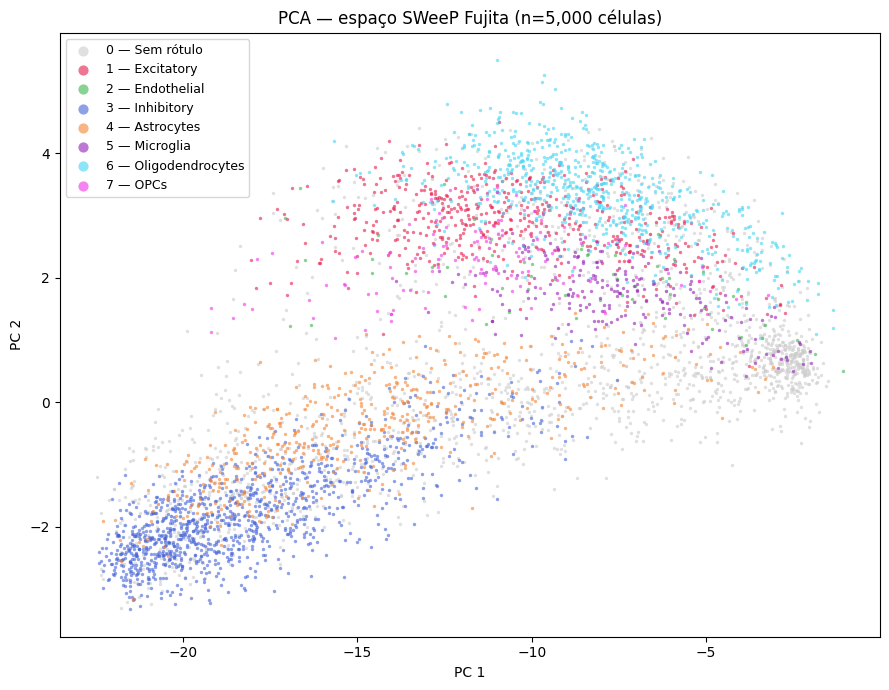

In [161]:
# PCA scatter — PC1 × PC2 colorido por tipo celular (amostra 5 000 células)
rng_pca = np.random.default_rng(SEED)
idx_pca = rng_pca.choice(len(projetor.Wpc), min(5000, len(projetor.Wpc)), replace=False)

CLASSE_NOMES = {0: 'Sem rótulo', 1: 'Excitatory', 2: 'Endothelial',
                3: 'Inhibitory',  4: 'Astrocytes', 5: 'Microglia',
                6: 'Oligodendrocytes', 7: 'OPCs'}
CORES = {0: '#cccccc', 1: '#e6194b', 2: '#3cb44b', 3: '#4363d8',
         4: '#f58231', 5: '#911eb4', 6: '#42d4f4', 7: '#f032e6'}

fig, ax = plt.subplots(figsize=(9, 7))
for cls in sorted(CORES):
    mask = clo[idx_pca] == cls
    if mask.any():
        ax.scatter(projetor.Wpc[idx_pca][mask, 0],
                   projetor.Wpc[idx_pca][mask, 1],
                   c=CORES[cls], label=f'{cls} — {CLASSE_NOMES[cls]}',
                   s=6, alpha=0.6, linewidths=0)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title(f'PCA — espaço SWeeP Fujita (n={len(idx_pca):,} células)')
ax.legend(markerscale=3, fontsize=9, loc='best')
plt.tight_layout(); plt.show()

## 9. Extração de padrões por subcluster (perf35)

Para cada uma das 7 classes executa KMeans com `nc=10` clusters no espaço
SWeeP e seleciona o vetor binário mais próximo de cada centroide como
representante. Resulta em `7 × 10 = 70 padrões`.

```matlab
for ii in classes:
    km = kmeans(Wswp[clo==ii], nc)
    for centroide in km.centroids:
        idx = closervects(Wswp[clo==ii], centroide, k=1)
        perf35.append(W0[clo==ii][idx])
```

In [162]:
extrator = ExtratorPadroesSubcluster(
    W0      = carregador.W0,
    labels  = clo,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = 10,
    seed    = SEED,
    k       = 1,
)
extrator.extrair(projetor.Wswp)
perf35 = extrator.padroes
print(extrator)
print(f'perf35 shape: {perf35.shape}  (esperado: (70, 5000))')

[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 2: n=433, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Extração concluída: 70 padrões (7 classes)
ExtratorPadroesSubcluster(
  W0       = (40913, 5000)
  labels   = (40913,)
  classes  = [1, 2, 3, 4, 5, 6, 7]
  nc       = 10
  k        = 1
  seed     = 42
  padroes  = (70, 5000)
)
perf35 shape: (70, 5000)  (esperado: (70, 5000))


## 10. Treinamento da rede (rede35)

Armazena os 70 padrões na Modern Hopfield Network.

**Regra de armazenamento:** simplesmente guardar os padrões — não há
treinamento iterativo.

**Parâmetros:**
- `beta=8.0`: temperatura inversa do softmax (maior → mais winner-takes-all)
- `n_iters=1`: uma iteração de atualização já é suficiente
- `threshold=0.5`: genes preenchidos com 0.5 (sentinela Mathys) são tratados
  como ausentes (< 0.5 → 0) na binarização da query

In [163]:
rede35 = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.0)
# threshold=0.0: limiar correto para binarização de saída bipolar (valores > 0 → gene ativo).
# O sentinela 0.5 do Mathys é tratado pela conversão bipolar Q = 2Q−1 (0.5 → 0.0 neutro
# no attention), sem necessidade de threshold na entrada.
rede35.store(perf35)
meta_eval = extrator.meta  # mapeamento padrao -> classe
print(rede35)

[ModernHopfieldNetwork] 70 padrões armazenados (dim=5000, device=cpu)
ModernHopfieldNetwork(
  beta       = 8.0
  n_iters    = 1
  binary     = True
  threshold  = 0.0
  padrões    = 70 × 5000
)


## 10b. Alternativa: carregar rede pre-treinada

**Use esta celula em vez das secoes 9 e 10** quando o treinamento foi feito
noutra maquina. Copie os arquivos rede35_v2.pt e rede35_v2_metadata.json para
a pasta outputs/hopfield/ desta maquina e execute apenas esta celula.

Se treinou aqui (secoes 9 e 10), **pule esta celula**.

In [164]:
import json as _json

PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35_v2.pt')
PATH_META = os.path.join(OUT_HOPFIELD, 'rede35_v2_metadata.json')

# Carrega rede e metadados
rede35 = ModernHopfieldNetwork.carregar(PATH_PT)

with open(PATH_META) as _f:
    _meta_json = _json.load(_f)

# Reconstrói perf35 em {0,1} a partir dos padrões salvos em {-1,+1}
perf35 = ((rede35.patterns.cpu().numpy() + 1.0) / 2.0).clip(0.0, 1.0).astype('float32')

# Variáveis de avaliação (substituem extrator.meta quando rede vem de fora)
meta_eval = [tuple(x) for x in _meta_json['meta']]

print(rede35)
print(f'perf35 shape: {perf35.shape}')
print(f'Classes: {_meta_json["classes"]}  nc={_meta_json["nc"]}  padroes={_meta_json["n_patterns"]}')

[ModernHopfieldNetwork] Rede carregada de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt (70 padrões × 5000 dim)
ModernHopfieldNetwork(
  beta       = 8.0
  n_iters    = 1
  binary     = True
  threshold  = 0.5
  padrões    = 70 × 5000
)
perf35 shape: (70, 5000)
Classes: [1, 2, 3, 4, 5, 6, 7]  nc=10  padroes=70


## 11. Teste numa subclasse (clo == 3)

Seguindo o padrão da seção 13 do `script01`: embaralha aleatoriamente as
células da classe 3 e testa as primeiras 1000 (amostra representativa).

```matlab
Wk4  = wsort(W0(clo==3, :));          % embaralhamento aleatório
Wtes = hopf_ts(Wk4(1:1000,:), rede35);
```

In [165]:
NC   = 10
CLASSES_ARR = np.array([1, 2, 3, 4, 5, 6, 7])

Wk4    = wsort(carregador.W0[clo == 3])
n_test = min(1000, Wk4.shape[0])
Wtes   = rede35.retrieve(Wk4[:n_test], batch_size=4096)
print(f'hopf_ts(Wk4[:{n_test}], rede35): shape {Wtes.shape}')

perf35_f = perf35.astype(np.float64)
Wtes_f   = Wtes.astype(np.float64)
a2 = (Wtes_f ** 2).sum(axis=1, keepdims=True)
b2 = (perf35_f ** 2).sum(axis=1, keepdims=True).T
idx_proto = (a2 + b2 - 2 * (Wtes_f @ perf35_f.T)).argmin(axis=1)
pred_sub  = CLASSES_ARR[idx_proto // NC]

acc_sub = (pred_sub == 3).mean()
print(f'\nAcurácia subclasse clo==3: {acc_sub * 100:.2f}%')

[ModernHopfieldNetwork] Recuperação concluída: torch.Size([1000, 5000])
hopf_ts(Wk4[:1000], rede35): shape (1000, 5000)

Acurácia subclasse clo==3: 88.50%


              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       1.00      0.89      0.94      1000
           4       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0

    accuracy                           0.89      1000
   macro avg       0.25      0.22      0.23      1000
weighted avg       1.00      0.89      0.94      1000



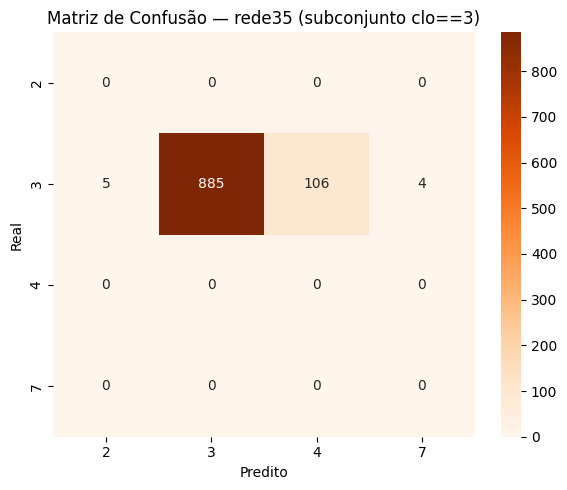

In [166]:
y_true_sub = np.full(n_test, 3)
labels_sub = sorted(set(y_true_sub) | set(pred_sub))
print(classification_report(y_true_sub, pred_sub, labels=labels_sub, zero_division=0))

cm_sub = confusion_matrix(y_true_sub, pred_sub, labels=labels_sub)
fig, ax = plt.subplots(figsize=(max(6, len(labels_sub)), max(5, len(labels_sub))))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_sub, yticklabels=labels_sub, ax=ax)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — rede35 (subconjunto clo==3)')
plt.tight_layout(); plt.show()

## 12. Auto-imputação — Fujita → Fujita

Baseline interno: a rede treinada em Fujita recebe as próprias células Fujita.
Esperamos alta taxa de reconstrução e classificação.

=== Auto-imputação: Fujita → Fujita ===
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([40913, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...
[AvaliadorHopfield] Acurácia: 92.22% (n=27,008)
[AvaliadorHopfield] F1 macro=0.8725, F1 ponderado=0.9255
[AvaliadorHopfield] Taxa de reconstrução exata : 99.24%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      0.94      0.97      4366
           2       0.41      0.71      0.52       433
           3       0.98      0.88      0.93      9073
           4       0.80      0.89      0.84      4567
           5       0.96      0.95      0.96      1734
           6       0.96      0.99      0.98      5762
           7       0.86      0.96      0.91      1073

    accuracy                           0.92     27008
   macro avg       0.85      0.90      0.87     27008
weighted avg       0.93      0.92      0.93     27008



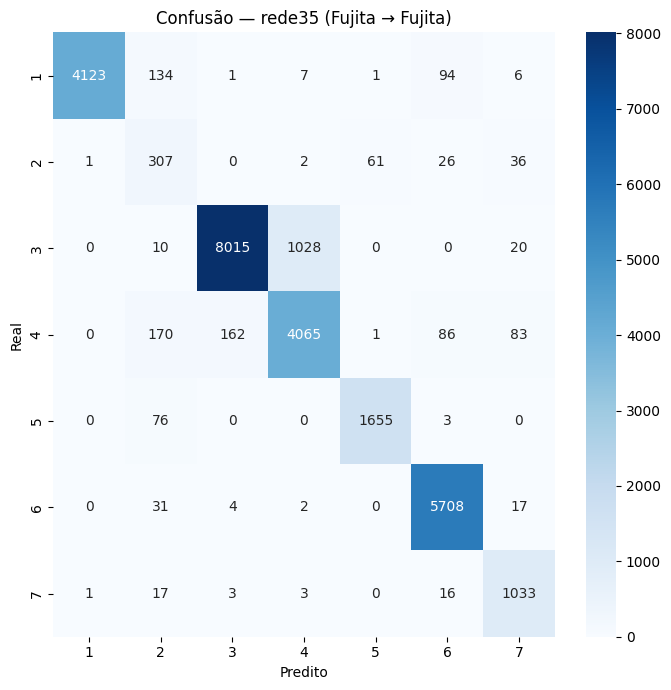

AvaliadorHopfield(
  padroes            = (70, 5000)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 10
  acuracia           = 92.22%
  f1_macro           = 0.8725
  f1_weighted        = 0.9255
  taxa_reconstrucao  = 99.24%
  semelhanca_media   = 0.9994
)


In [167]:
print('=== Auto-imputação: Fujita → Fujita ===')
Wrecuperado_f = rede35.retrieve(carregador.W0, batch_size=4096)

avaliador_f = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = 10,
    meta    = meta_eval,
)
avaliador_f.avaliar(Wrecuperado_f, clo).plotar(titulo='Confusão — rede35 (Fujita → Fujita)')
print(avaliador_f)

## 13. Imputação cross-dataset — Mathys com sentinela 0.5

A rede treinada em Fujita recebe células do Mathys. Os 6 289 genes ausentes
no Mathys foram preenchidos com `0.5` pelo `Alinhador` — o limiar `threshold=0.5`
da rede os trata como ausentes (0) na binarização da query antes da recuperação.

=== Imputação cross-dataset: Mathys (com sentinela 0.5) ===
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...
[AvaliadorHopfield] Acurácia: 66.46% (n=45,663)
[AvaliadorHopfield] F1 macro=0.6252, F1 ponderado=0.7069
[AvaliadorHopfield] Taxa de reconstrução exata : 99.02%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9993
              precision    recall  f1-score   support

           1       1.00      0.50      0.67      2597
           2       0.02      0.72      0.04       159
           3       1.00      0.57      0.72     24548
           4       0.43      0.57      0.49      6420
           5       0.94      0.86      0.90       485
           6       0.70      1.00      0.82      9218
           7       0.69      0.80      0.74      2236

    accuracy                           0.66     45663
   macro avg       0.68      0.71      0.63     45663
weighted avg       0.84      0.66      0.

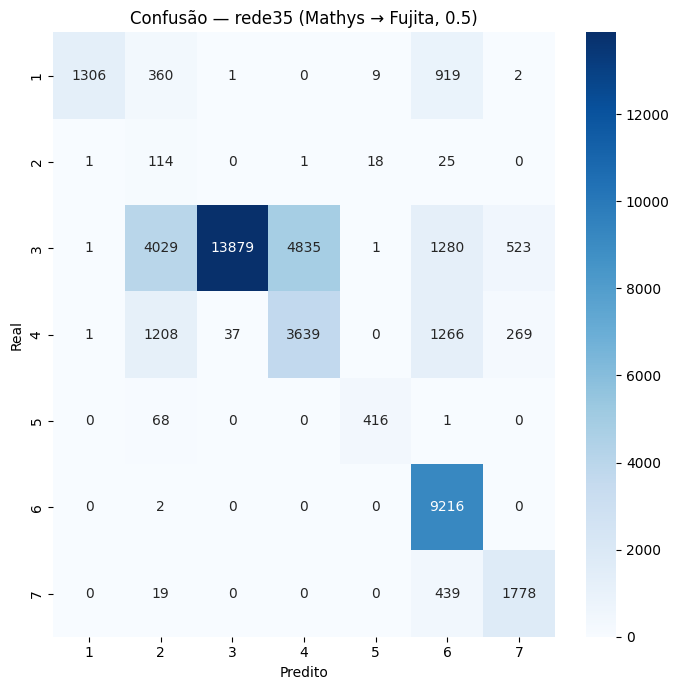

AvaliadorHopfield(
  padroes            = (70, 5000)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 10
  acuracia           = 66.46%
  f1_macro           = 0.6252
  f1_weighted        = 0.7069
  taxa_reconstrucao  = 99.02%
  semelhanca_media   = 0.9993
)


In [168]:
print('=== Imputação cross-dataset: Mathys (com sentinela 0.5) ===')
Wrecuperado_m = rede35.retrieve(W_mathys, batch_size=4096)

avaliador_m = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = 10,
    meta    = meta_eval,
)
avaliador_m.avaliar(Wrecuperado_m, clo_m).plotar(titulo='Confusão — rede35 (Mathys → Fujita, 0.5)')
print(avaliador_m)

## 14. Imputação cross-dataset — Mathys binário puro (0.5 → 0)

Comparação: converte os valores sentinela `0.5 → 0` antes da recuperação,
equivalente a tratar todos os genes ausentes como definitivamente inativos.
Permite comparar o impacto do sentinela `0.5` na qualidade da recuperação.

Valores convertidos de 0.5 → 0: 4292322
Valores únicos após conversão: [0. 1.]

=== Imputação cross-dataset: Mathys (binário puro, sem 0.5) ===
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...
[AvaliadorHopfield] Acurácia: 64.90% (n=45,663)
[AvaliadorHopfield] F1 macro=0.6114, F1 ponderado=0.6936
[AvaliadorHopfield] Taxa de reconstrução exata : 99.05%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      0.47      0.64      2597
           2       0.02      0.72      0.04       159
           3       1.00      0.55      0.71     24548
           4       0.42      0.54      0.47      6420
           5       0.94      0.84      0.89       485
           6       0.70      1.00      0.82      9218
           7       0.67      0.78      0.72      2236

    accuracy                           0.65     45663
   macro av

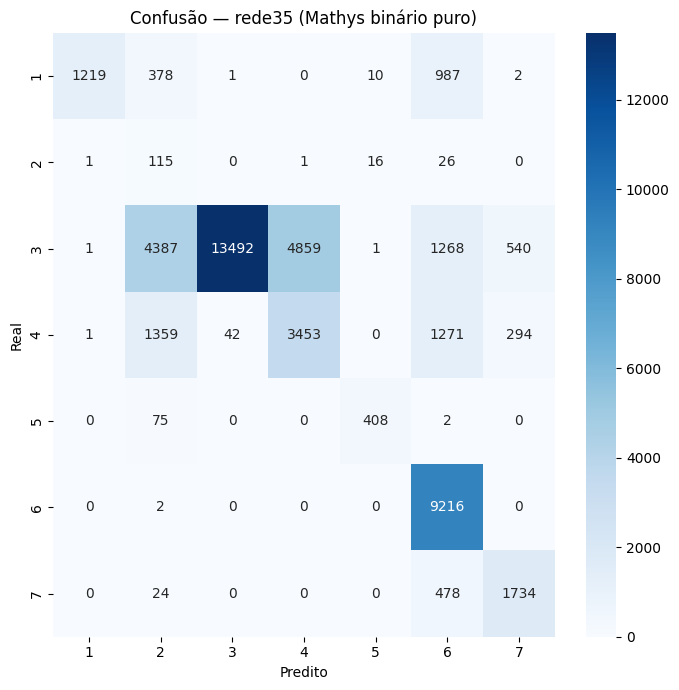

AvaliadorHopfield(
  padroes            = (70, 5000)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 10
  acuracia           = 64.90%
  f1_macro           = 0.6114
  f1_weighted        = 0.6936
  taxa_reconstrucao  = 99.05%
  semelhanca_media   = 0.9994
)


In [169]:
W_mathys_bin = W_mathys.copy()
n_meio = int((W_mathys_bin == 0.5).sum())
W_mathys_bin[W_mathys_bin == 0.5] = 0.0
print(f'Valores convertidos de 0.5 → 0: {n_meio}')
print(f'Valores únicos após conversão: {np.unique(W_mathys_bin)}')

print('\n=== Imputação cross-dataset: Mathys (binário puro, sem 0.5) ===')
Wrecuperado_m_bin = rede35.retrieve(W_mathys_bin, batch_size=4096)

avaliador_m_bin = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = 10,
    meta    = meta_eval,
)
avaliador_m_bin.avaliar(Wrecuperado_m_bin, clo_m).plotar(titulo='Confusão — rede35 (Mathys binário puro)')
print(avaliador_m_bin)

In [170]:

# --- Diagnóstico: mapeamento de classes Mathys → protótipos Fujita ---

print("=== Diagnóstico: distribuição de protótipos selecionados por classe Mathys ===\n")

perf_f64 = perf35.astype(np.float64)
Wm_f64   = Wrecuperado_m.astype(np.float64)
a2 = (Wm_f64 ** 2).sum(axis=1, keepdims=True)
b2 = (perf_f64 ** 2).sum(axis=1, keepdims=True).T
idx_proto_m = (a2 + b2 - 2 * (Wm_f64 @ perf_f64.T)).argmin(axis=1)
pred_m = np.array([meta_eval[i][0] for i in idx_proto_m])

classes_eval = [1, 2, 3, 4, 5, 6, 7]
CM_diag = pd.DataFrame(0, index=classes_eval, columns=classes_eval, dtype=int)
CM_diag.index.name   = 'Mathys (verdadeiro)'
CM_diag.columns.name = 'Fujita (predito)'

for true_c, pred_c in zip(clo_m, pred_m):
    if true_c in classes_eval and pred_c in classes_eval:
        CM_diag.loc[true_c, pred_c] += 1

print("Mapeamento Mathys → protótipos Fujita (contagens):")
display(CM_diag)

# Convergência: fração de posições que mudaram após retrieve()
# Comparação limitada às posições não-sentinela (onde W_mathys é 0 ou 1)
mask_nao_sentinela = (W_mathys != 0.5)
diff_frac = float((W_mathys[mask_nao_sentinela] != Wrecuperado_m[mask_nao_sentinela]).mean())
print(f"\nFração de genes não-sentinela alterados após retrieve(): {diff_frac:.4f}")
print("  ≈ 0 → rede não está modificando as células (verificar configuração)")
print("  > 0 → a rede está realizando a recuperação corretamente")


=== Diagnóstico: distribuição de protótipos selecionados por classe Mathys ===

Mapeamento Mathys → protótipos Fujita (contagens):


Fujita (predito),1,2,3,4,5,6,7
Mathys (verdadeiro),,,,,,,
1,1306,360,1,0,9,919,2
2,1,114,0,1,18,25,0
3,1,4029,13879,4835,1,1280,523
4,1,1208,37,3639,0,1266,269
5,0,68,0,0,416,1,0
6,0,2,0,0,0,9216,0
7,0,19,0,0,0,439,1778



Fração de genes não-sentinela alterados após retrieve(): 0.2723
  ≈ 0 → rede não está modificando as células (verificar configuração)
  > 0 → a rede está realizando a recuperação corretamente


## 15. Persistência da rede

In [171]:
import json as _json

os.makedirs(OUT_HOPFIELD, exist_ok=True)
path_rede_v2 = os.path.join(OUT_HOPFIELD, 'rede35_v2.pt')
path_meta_v2 = os.path.join(OUT_HOPFIELD, 'rede35_v2_metadata.json')

# Salva rede
rede35.salvar(path_rede_v2)

# Salva metadados (necessários para AvaliadorHopfield na máquina de aplicação)
_metadata = {
    'classes'   : [1, 2, 3, 4, 5, 6, 7],
    'nc'        : 10,
    'n_patterns': int(perf35.shape[0]),
    'n_genes'   : int(perf35.shape[1]),
    'meta'      : [[int(c_), int(idx)] for c_, idx in extrator.meta],
}
with open(path_meta_v2, 'w') as _f:
    _json.dump(_metadata, _f, indent=2)

print(f'Rede salva em    : {path_rede_v2}')
print(f'Metadados salvos : {path_meta_v2}')
print('Para carregar: rede = ModernHopfieldNetwork.carregar(path)')

[ModernHopfieldNetwork] Rede salva em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt (70 padrões × 5000 dim)
Rede salva em    : c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt
Metadados salvos : c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2_metadata.json
Para carregar: rede = ModernHopfieldNetwork.carregar(path)


## Notas finais

**Diferenças em relação ao `pipilinePrincipal.ipynb`:**
- Inclui remapeamento de classes `clo` (padrão do script01): classes raras → 2.
- Inclui teste em subclasse (seção 11) e auto-imputação Fujita→Fujita (seção 12).
- Avalia tanto Mathys com sentinela `0.5` quanto Mathys binário puro.

**Hiperparâmetros:**
- `beta`: controla a nitidez da recuperação. Para padrões esparsos de alta
  dimensão, valores entre 4 e 16 costumam funcionar bem.
- `nc`: número de subclusters por classe. Aumentar aumenta a capacidade de
  representar variabilidade intraclasse.
- `k`: número de representantes por centroide. `k=1` usa o indivíduo mais
  próximo; `k>1` pode ser usado para padrões de consenso.

**Classes utilizadas (src/):**
```
preprocessing/  → Binarizador
alinhamento/    → LeitorFeatures, AnalisadorSobreposicao, Alinhador,
                   ValidadorAlinhamento, SelecionadorGenesFrequentes, AnalisadorCobertura
treinamento/    → GeradorConjuntoTreinamento, CarregadorDadosFujita,
                   ProjetorSWeP, ProjetorSWeePR, ExtratorPadroesSubcluster,
                   ModernHopfieldNetwork, AvaliadorHopfield
```

## 16. Análise Comparativa — Fujita vs Mathys

Consolida as matrizes de confusão e as métricas de reconstrução dos três cenários
avaliados nas seções 12, 13 e 14 para facilitar a comparação direta.

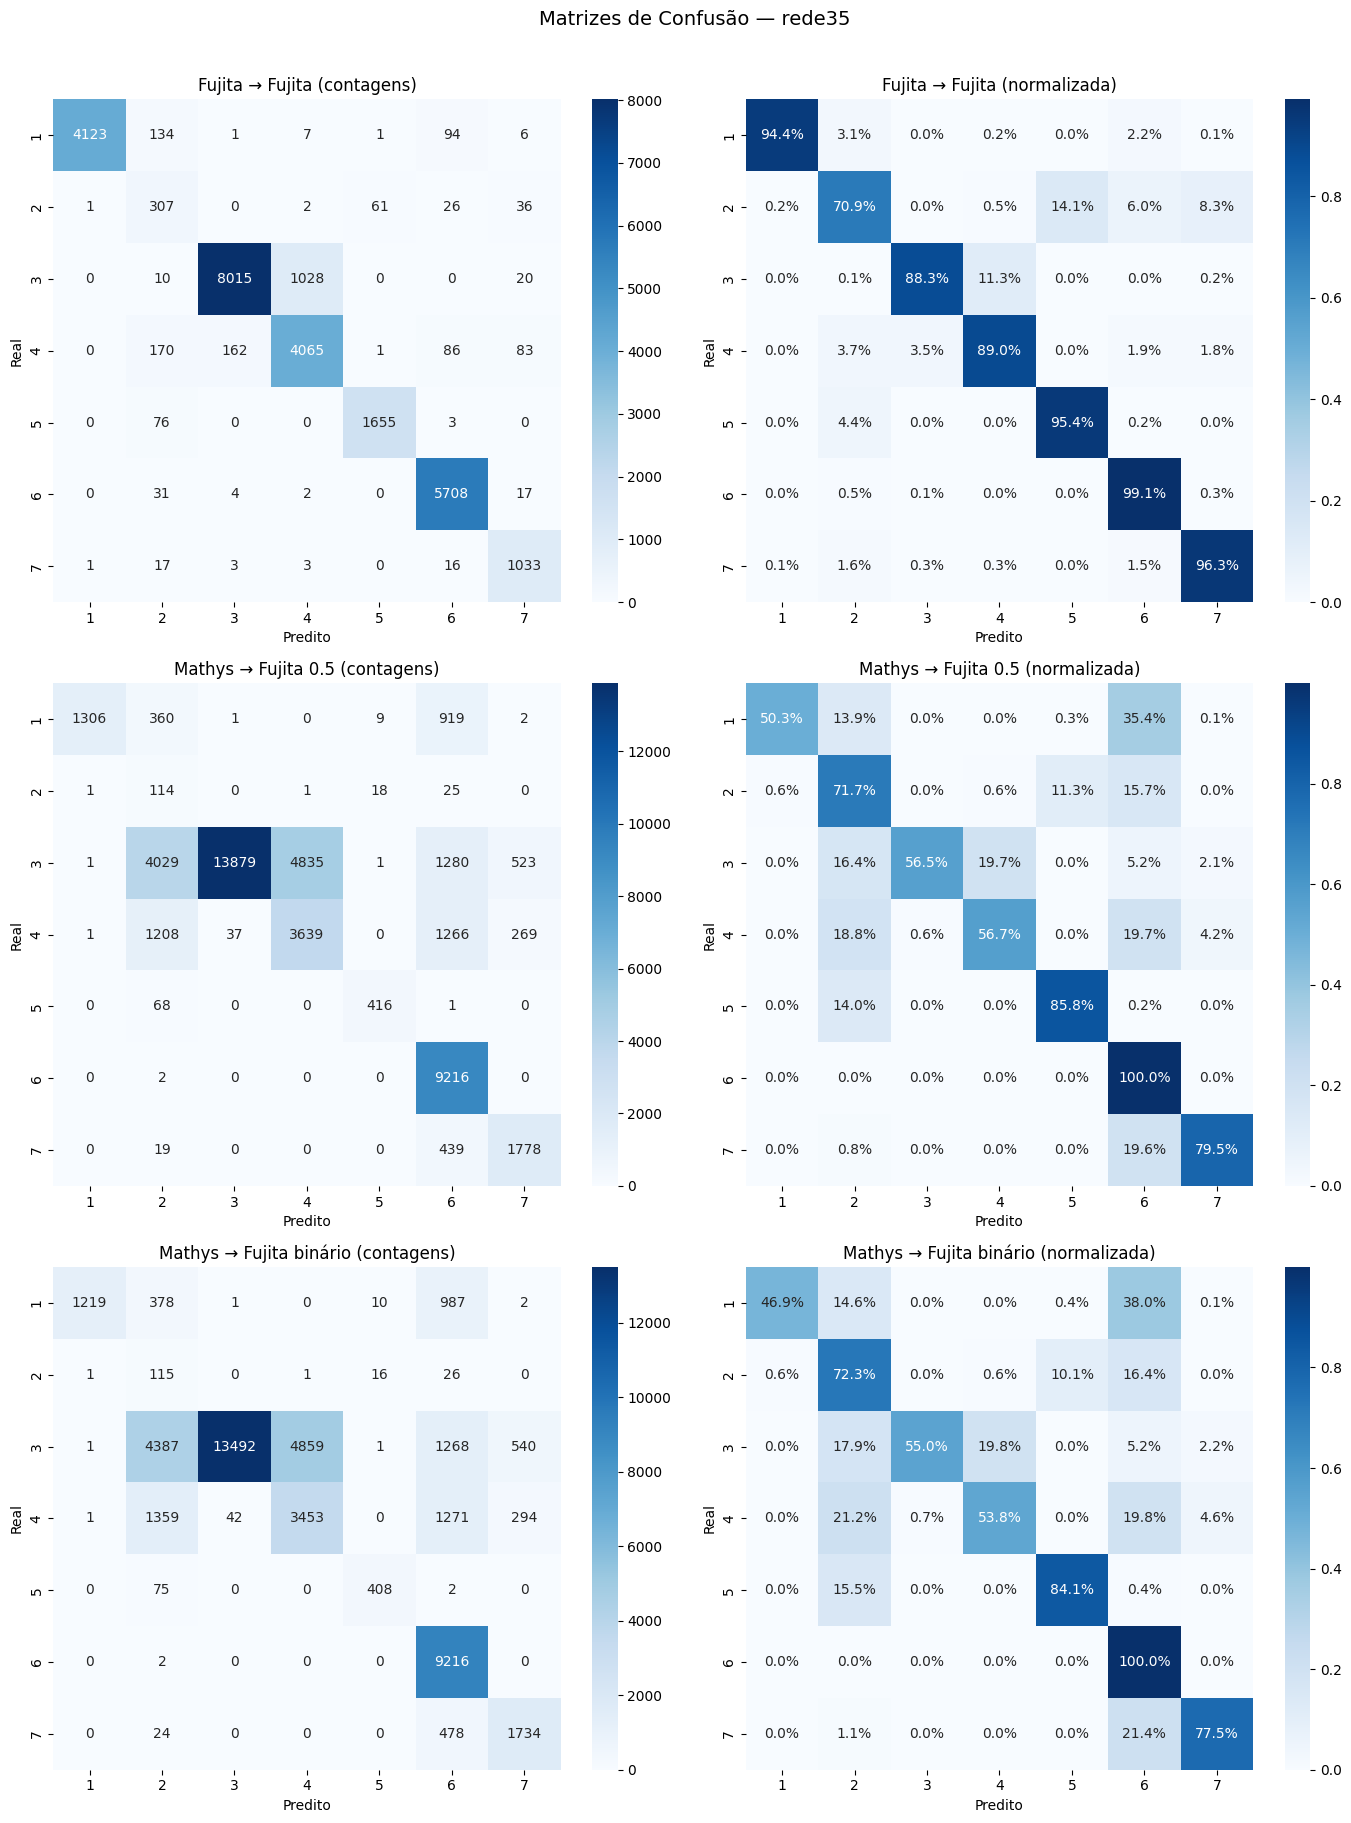

In [172]:
# Matrizes de confusão — contagens e normalizadas (todos os cenários)
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

avaliador_f.plotar(    titulo='Fujita → Fujita (contagens)',          ax=axes[0, 0])
avaliador_f.plotar(    titulo='Fujita → Fujita (normalizada)',         ax=axes[0, 1], normalizado=True)
avaliador_m.plotar(    titulo='Mathys → Fujita 0.5 (contagens)',       ax=axes[1, 0])
avaliador_m.plotar(    titulo='Mathys → Fujita 0.5 (normalizada)',     ax=axes[1, 1], normalizado=True)
avaliador_m_bin.plotar(titulo='Mathys → Fujita binário (contagens)',   ax=axes[2, 0])
avaliador_m_bin.plotar(titulo='Mathys → Fujita binário (normalizada)', ax=axes[2, 1], normalizado=True)

plt.suptitle('Matrizes de Confusão — rede35', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 16b. t-SNE — estrutura global das células

Visualização não-linear da separação entre tipos celulares em duas dimensões.

**Passo A** — t-SNE dos 5 000 Fujita no espaço SWeeP (primeiros 50 PCs):
mostra se os tipos celulares formam ilhas distintas no espaço de baixa dimensionalidade.

**Passo B** — t-SNE conjunto (Fujita ● + Mathys ▲ reconstruídos, 5 000 de cada):
células do mesmo tipo das duas espécies devem se sobrepor se a reconstrução
pela Hopfield Network preservou as identidades celulares. Divergência = sinal de
perda de informação no alinhamento cross-dataset.

Rodando t-SNE em 5000 células Fujita (input: primeiros 50 PCs)...
  Concluído.


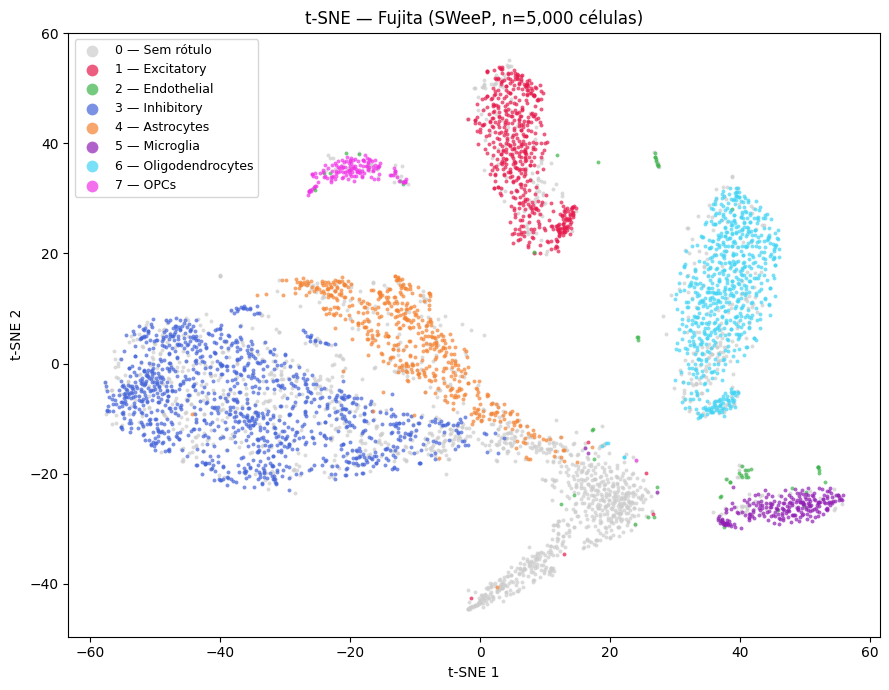

Ajustando PCA em espaço gênico (5000 dims → 50)...
Rodando t-SNE conjunto (10,000 células)...
  Concluído.


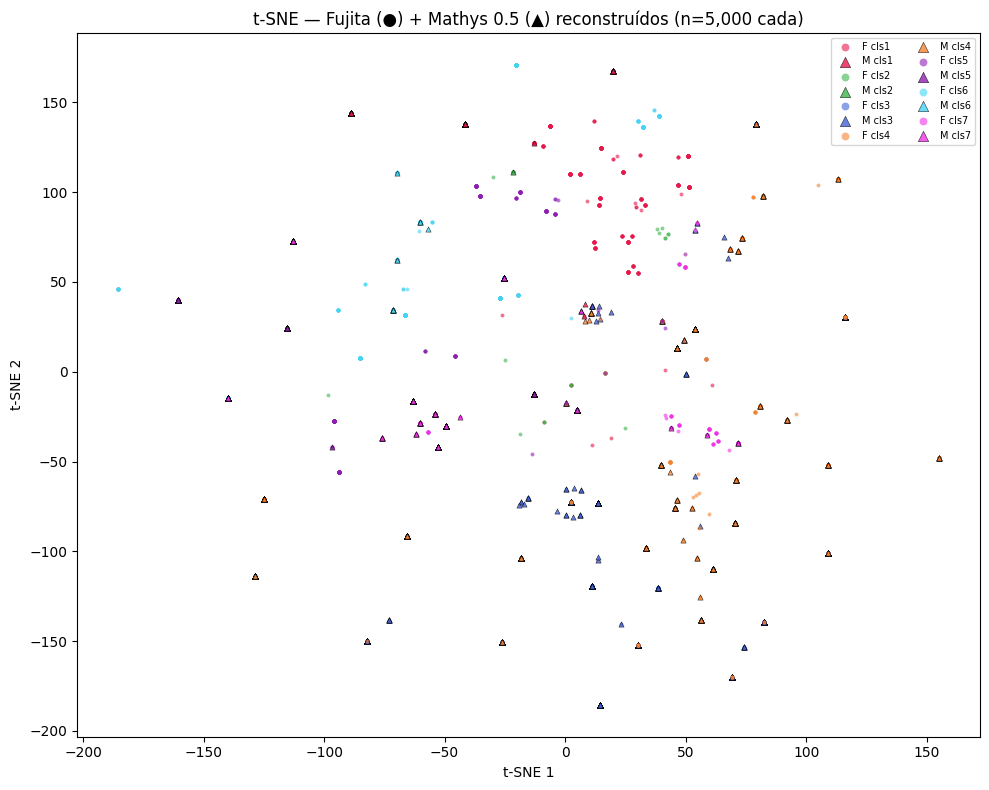

In [173]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA as SkPCA

# ── Passo A: t-SNE de Fujita no espaço SWeeP ──────────────────────────────
rng_tsne = np.random.default_rng(SEED)
N_TSNE = 5000
idx_f_t = rng_tsne.choice(len(projetor.Wpc), N_TSNE, replace=False)

print(f'Rodando t-SNE em {N_TSNE} células Fujita (input: primeiros 50 PCs)...')
tsne_a = TSNE(n_components=2, perplexity=40, random_state=SEED, n_jobs=-1)
Z_f = tsne_a.fit_transform(projetor.Wpc[idx_f_t, :50])
print('  Concluído.')

fig, ax = plt.subplots(figsize=(9, 7))
for cls in sorted(CORES):
    mask = clo[idx_f_t] == cls
    if mask.any():
        ax.scatter(Z_f[mask, 0], Z_f[mask, 1],
                   c=CORES[cls], label=f'{cls} — {CLASSE_NOMES[cls]}',
                   s=8, alpha=0.7, linewidths=0)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE — Fujita (SWeeP, n={N_TSNE:,} células)')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout(); plt.show()

# ── Passo B: t-SNE Fujita + Mathys (0.5) reconstruído ────────────────────
print('Ajustando PCA em espaço gênico (5000 dims → 50)...')
pca_gene = SkPCA(n_components=50, random_state=SEED)
pca_gene.fit(carregador.W0)

idx_m_t = rng_tsne.choice(len(Wrecuperado_m), N_TSNE, replace=False)
X_f_rec = pca_gene.transform(Wrecuperado_f[idx_f_t])   # Fujita reconstruído
X_m_rec = pca_gene.transform(Wrecuperado_m[idx_m_t])   # Mathys reconstruído
X_joint = np.vstack([X_f_rec, X_m_rec])

print(f'Rodando t-SNE conjunto ({2*N_TSNE:,} células)...')
tsne_b = TSNE(n_components=2, perplexity=40, random_state=SEED, n_jobs=-1)
Z_joint = tsne_b.fit_transform(X_joint)
print('  Concluído.')

Z_fj = Z_joint[:N_TSNE]
Z_mj = Z_joint[N_TSNE:]

fig, ax = plt.subplots(figsize=(10, 8))
for cls in sorted(CORES):
    if cls == 0:
        continue
    mf = clo[idx_f_t]   == cls
    mm = clo_m[idx_m_t] == cls
    if mf.any():
        ax.scatter(Z_fj[mf, 0], Z_fj[mf, 1], c=CORES[cls], s=8,
                   alpha=0.6, linewidths=0, marker='o', label=f'F cls{cls}')
    if mm.any():
        ax.scatter(Z_mj[mm, 0], Z_mj[mm, 1], c=CORES[cls], s=14,
                   alpha=0.8, linewidths=0.4, marker='^',
                   edgecolors='k', label=f'M cls{cls}')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE — Fujita (●) + Mathys 0.5 (▲) reconstruídos (n={N_TSNE:,} cada)')
ax.legend(markerscale=2, fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

## 16c. DBSCAN — validação de clusters não-supervisionada

Aplica DBSCAN sobre as coordenadas t-SNE 2D do Fujita (Passo A acima) para verificar
se os clusters de densidade concordam com os rótulos biológicos `clo`.

- **Curva k-NN**: ordena as distâncias ao k-ésimo vizinho — o "cotovelo" indica o
  valor ideal de `eps`. Ajuste `EPS` na célula abaixo se necessário.
- **ARI (Adjusted Rand Index)**: quantifica o acordo entre DBSCAN e `clo`.
  ARI ≈ 1 → clusters não-supervisionados capturam os tipos celulares.
  ARI ≈ 0 → resultado aleatório.

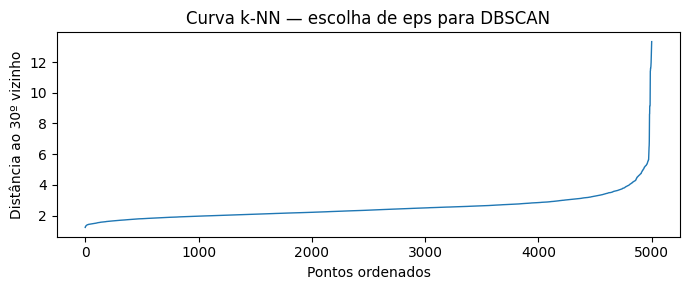

Clusters encontrados: 32  |  Pontos de ruído: 2111 (42.2%)
ARI (DBSCAN vs clo, excl. classe 0): 0.2213
  ARI = 1 → clusters concordam perfeitamente com os rótulos biológicos
  ARI ≈ 0 → concordância aleatória


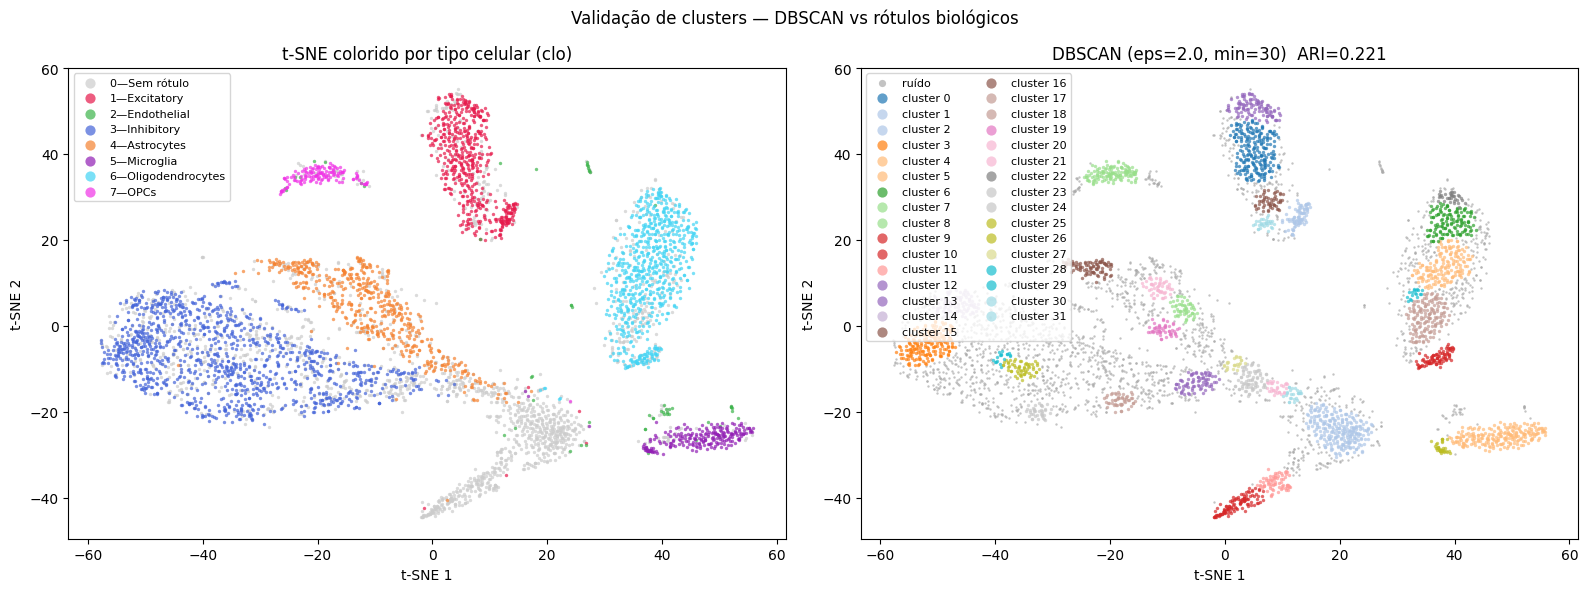

In [174]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

# ── Escolha visual de eps (curva k-NN) ────────────────────────────────────
k_nn = 30
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(Z_f)
dists, _ = nbrs.kneighbors(Z_f)
knn_dists = np.sort(dists[:, -1])

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(knn_dists, lw=1)
ax.set_xlabel('Pontos ordenados'); ax.set_ylabel(f'Distância ao {k_nn}º vizinho')
ax.set_title('Curva k-NN — escolha de eps para DBSCAN')
plt.tight_layout(); plt.show()

# ── DBSCAN nas coordenadas t-SNE Fujita ───────────────────────────────────
EPS        = 2.0    # ajuste com base na curva acima se necessário
MIN_SAMP   = 30

db = DBSCAN(eps=EPS, min_samples=MIN_SAMP).fit(Z_f)
labels_db  = db.labels_
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido    = (labels_db == -1).sum()
print(f'Clusters encontrados: {n_clusters}  |  Pontos de ruído: {n_ruido} ({n_ruido/len(labels_db):.1%})')

# Apenas pontos com rótulo clo ≠ 0 para o ARI
mask_clo  = clo[idx_f_t] != 0
ari = adjusted_rand_score(clo[idx_f_t][mask_clo], labels_db[mask_clo])
print(f'ARI (DBSCAN vs clo, excl. classe 0): {ari:.4f}')
print('  ARI = 1 → clusters concordam perfeitamente com os rótulos biológicos')
print('  ARI ≈ 0 → concordância aleatória')

# ── Plot comparativo: clo vs DBSCAN ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for cls in sorted(CORES):
    m = clo[idx_f_t] == cls
    if m.any():
        ax.scatter(Z_f[m, 0], Z_f[m, 1], c=CORES[cls],
                   label=f'{cls}—{CLASSE_NOMES[cls]}', s=6, alpha=0.7, linewidths=0)
ax.set_title('t-SNE colorido por tipo celular (clo)')
ax.legend(markerscale=3, fontsize=8)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

ax = axes[1]
uniq_db = sorted(set(labels_db))
cmap_db = plt.get_cmap('tab20', len(uniq_db))
for i, lbl in enumerate(uniq_db):
    m = labels_db == lbl
    nome = 'ruído' if lbl == -1 else f'cluster {lbl}'
    cor  = '#aaaaaa' if lbl == -1 else cmap_db(i)
    ax.scatter(Z_f[m, 0], Z_f[m, 1], c=[cor], label=nome,
               s=6 if lbl != -1 else 3, alpha=0.7, linewidths=0)
ax.set_title(f'DBSCAN (eps={EPS}, min={MIN_SAMP})  ARI={ari:.3f}')
ax.legend(markerscale=3, fontsize=8, ncol=2)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.suptitle('Validação de clusters — DBSCAN vs rótulos biológicos', fontsize=12)
plt.tight_layout(); plt.show()

In [175]:
# Tabela de métricas globais — comparação entre os três cenários
df_resumo = pd.DataFrame([
    avaliador_f.metricas_resumo('Fujita → Fujita'),
    avaliador_m.metricas_resumo('Mathys → Fujita (0.5)'),
    avaliador_m_bin.metricas_resumo('Mathys → Fujita (bin)'),
]).set_index('dataset')

display(df_resumo.style
    .format({
        'n_celulas':         '{:,}',
        'acuracia':          '{:.2%}',
        'f1_macro':          '{:.4f}',
        'f1_weighted':       '{:.4f}',
        'taxa_reconstrucao': '{:.2%}',
        'semelhanca_media':  '{:.4f}',
    })
    .set_caption('Métricas de Reconstrução — rede35')
    .highlight_max(color='lightgreen', axis=0)
)

,n_celulas,acuracia,f1_macro,f1_weighted,taxa_reconstrucao,semelhanca_media
dataset,,,,,,
Fujita → Fujita,"27,008",92.22%,0.8725,0.9255,99.24%,0.9994
Mathys → Fujita (0.5),"45,663",66.46%,0.6252,0.7069,99.02%,0.9993
Mathys → Fujita (bin),"45,663",64.90%,0.6114,0.6936,99.05%,0.9994


In [176]:
# Métricas por classe — precision, recall e F1 para cada dataset
print('=== Fujita → Fujita ===')
display(avaliador_f.metricas_por_classe())

print('=== Mathys → Fujita (0.5) ===')
display(avaliador_m.metricas_por_classe())

print('=== Mathys → Fujita (binário puro) ===')
display(avaliador_m_bin.metricas_por_classe())

=== Fujita → Fujita ===


,classe,n_celulas,precisao,recall,f1
0,1,4366,0.9995,0.9443,0.9711
1,2,433,0.4121,0.7090,0.5212
2,3,9073,0.9792,0.8834,0.9288
3,4,4567,0.7960,0.8901,0.8404
4,5,1734,0.9633,0.9544,0.9589
5,6,5762,0.9621,0.9906,0.9761
6,7,1073,0.8644,0.9627,0.9109


=== Mathys → Fujita (0.5) ===


,classe,n_celulas,precisao,recall,f1
0,1,2597,0.9977,0.5029,0.6687
1,2,159,0.0197,0.7170,0.0383
2,3,24548,0.9973,0.5654,0.7216
3,4,6420,0.4294,0.5668,0.4886
4,5,485,0.9369,0.8577,0.8956
5,6,9218,0.7010,0.9998,0.8242
6,7,2236,0.6913,0.7952,0.7396


=== Mathys → Fujita (binário puro) ===


,classe,n_celulas,precisao,recall,f1
0,1,2597,0.9975,0.4694,0.6384
1,2,159,0.0181,0.7233,0.0354
2,3,24548,0.9968,0.5496,0.7086
3,4,6420,0.4154,0.5379,0.4687
4,5,485,0.9379,0.8412,0.8870
5,6,9218,0.6957,0.9998,0.8204
6,7,2236,0.6747,0.7755,0.7216


## 18. Reconstrução dos Genes Ausentes no Mathys

Analisa como a rede reconstruiu os genes do top-5000 que estavam **ausentes no Mathys**
(preenchidos com sentinela `0.5` no alinhamento), comparando os dois cenários:

- **0.5 (sentinela):** genes ausentes → `0.0` em bipolar → **neutros** no attention (não influenciam o padrão recuperado)
- **bin (binário puro):** genes ausentes → `−1.0` em bipolar → **negativos** no attention (suprimem padrões que expressam esses genes)

**Referência:** taxa de ativação desses mesmos genes nas células Fujita (ground truth).

In [177]:
# --- Identificação dos genes ausentes e métricas por gene ---

# 1. Genes do top-5000 ausentes no Mathys
df_cob    = pd.read_csv(os.path.join(OUT_ALINHAMENTO, 'top5000_cobertura_mathys.csv'))
ausentes  = df_cob[df_cob['presente_mathys'] == False].copy()
print(f'Genes ausentes no Mathys (top-5000): {len(ausentes)}')

# 2. Mapa Ensembl ID → índice de coluna no arquivo top-5000
with open(path_f_top5k, encoding='utf-8') as fh:
    top5k_header = fh.readline().strip().split(',')
gene_to_col         = {g: i for i, g in enumerate(top5k_header)}
ausentes['col_idx'] = ausentes['ensembl_id'].map(gene_to_col)
ausentes            = ausentes.dropna(subset=['col_idx'])
col_idx             = ausentes['col_idx'].astype(int).values
gene_ids            = ausentes['ensembl_id'].values
freqs               = ausentes['frequencia'].values
print(f'Colunas localizadas na matriz: {len(col_idx)}')

# 3. Taxa de ativação por gene em cada condição
#    carregador.W0   (células_F × 5000)  — referência Fujita
#    Wrecuperado_m   (células_M × 5000)  — reconstruído com 0.5
#    Wrecuperado_m_bin (células_M × 5000) — reconstruído com 0.0
rate_ref  = carregador.W0[:, col_idx].mean(axis=0)
rate_m05  = Wrecuperado_m[:, col_idx].mean(axis=0)
rate_mbin = Wrecuperado_m_bin[:, col_idx].mean(axis=0)

# 4. Erro absoluto médio
mae_05  = float(np.abs(rate_m05  - rate_ref).mean())
mae_bin = float(np.abs(rate_mbin - rate_ref).mean())
print(f'\nMAE cenário 0.5 vs Fujita  : {mae_05:.4f}')
print(f'MAE cenário bin vs Fujita  : {mae_bin:.4f}')
vencedor = '0.5 (sentinela)' if mae_05 < mae_bin else 'binário puro'
print(f'Cenário mais próximo da referência: {vencedor}')

# 5. Tabela por gene
df_ausentes = pd.DataFrame({
    'gene'        : gene_ids,
    'frequencia'  : freqs,
    'ref_fujita'  : rate_ref.round(4),
    'rec_05'      : rate_m05.round(4),
    'rec_bin'     : rate_mbin.round(4),
    'diff_05_ref' : (rate_m05  - rate_ref).round(4),
    'diff_bin_ref': (rate_mbin - rate_ref).round(4),
})
display(df_ausentes.sort_values('frequencia', ascending=False).reset_index(drop=True))

Genes ausentes no Mathys (top-5000): 94
Colunas localizadas na matriz: 94

MAE cenário 0.5 vs Fujita  : 0.1974
MAE cenário bin vs Fujita  : 0.2066
Cenário mais próximo da referência: 0.5 (sentinela)


,gene,frequencia,ref_fujita,rec_05,rec_bin,diff_05_ref,diff_bin_ref
0,ENSG00000224078,38439,0.9395,0.6044,0.5985,-0.3352,-0.3410
1,ENSG00000263001,32786,0.8014,0.3445,0.3323,-0.4568,-0.4691
2,ENSG00000255248,29839,0.7293,0.2735,0.2608,-0.4558,-0.4685
3,ENSG00000283154,28091,0.6866,0.3971,0.3852,-0.2895,-0.3014
4,ENSG00000247556,26442,0.6463,0.2750,0.2622,-0.3713,-0.3841
...,...,...,...,...,...,...,...
89,ENSG00000274422,11345,0.2773,0.1493,0.1478,-0.1280,-0.1295
90,ENSG00000286699,11335,0.2771,0.1349,0.1257,-0.1421,-0.1513
91,ENSG00000196369,11316,0.2766,0.1855,0.1748,-0.0911,-0.1018
92,ENSG00000265808,11266,0.2754,0.1374,0.1320,-0.1380,-0.1434


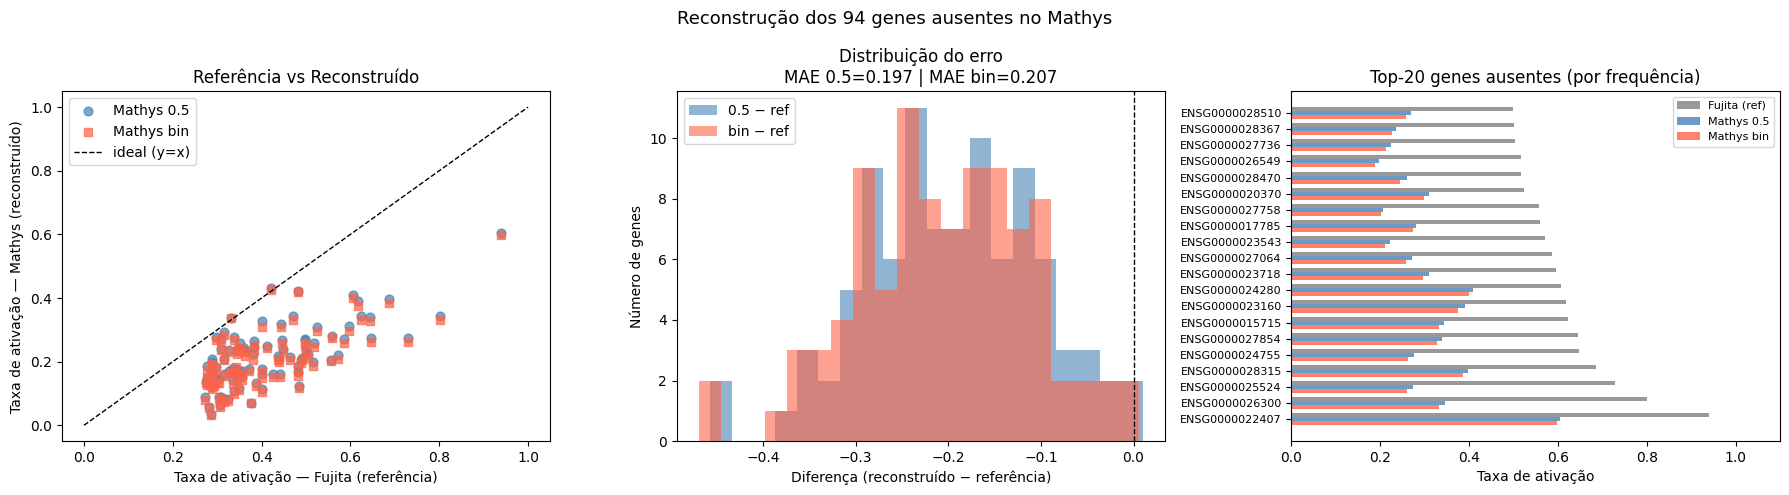

In [178]:

# --- Visualizações: reconstrução dos genes ausentes ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Reconstrução dos {len(col_idx)} genes ausentes no Mathys', fontsize=13)

# Plot 1: taxa de referência vs taxa reconstruída (ambos cenários)
ax = axes[0]
ax.scatter(rate_ref, rate_m05,  alpha=0.7, label='Mathys 0.5', color='steelblue', s=40)
ax.scatter(rate_ref, rate_mbin, alpha=0.7, label='Mathys bin', color='tomato',    s=40, marker='s')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='ideal (y=x)')
ax.set_xlabel('Taxa de ativação — Fujita (referência)')
ax.set_ylabel('Taxa de ativação — Mathys (reconstruído)')
ax.set_title('Referência vs Reconstruído')
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# Plot 2: distribuição da diferença (reconstruído − referência) por cenário
ax = axes[1]
ax.hist(rate_m05  - rate_ref, bins=20, alpha=0.6, label='0.5 − ref', color='steelblue')
ax.hist(rate_mbin - rate_ref, bins=20, alpha=0.6, label='bin − ref', color='tomato')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel('Diferença (reconstruído − referência)')
ax.set_ylabel('Número de genes')
ax.set_title(f'Distribuição do erro\nMAE 0.5={mae_05:.3f} | MAE bin={mae_bin:.3f}')
ax.legend()

# Plot 3: barras horizontais — top-20 genes por frequência, taxa nas 3 condições
ax = axes[2]
n_show = min(20, len(col_idx))
ordem  = np.argsort(freqs)[::-1][:n_show]
y_pos  = np.arange(n_show)
h      = 0.25
ax.barh(y_pos + h,  rate_ref[ordem],  h, label='Fujita (ref)', color='gray',      alpha=0.8)
ax.barh(y_pos,      rate_m05[ordem],  h, label='Mathys 0.5',   color='steelblue', alpha=0.8)
ax.barh(y_pos - h,  rate_mbin[ordem], h, label='Mathys bin',   color='tomato',    alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([gene_ids[i][:14] for i in ordem], fontsize=8)
ax.set_xlabel('Taxa de ativação')
ax.set_title(f'Top-{n_show} genes ausentes (por frequência)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.show()


## 17. Relatório Final do Experimento

Gera relatório HTML autocontido com:
- Metadados completos do experimento (topologia da rede, hiperparâmetros, dimensões dos datasets)
- Métricas globais e por classe para os três cenários de avaliação
- Matrizes de confusão (contagens e normalizadas)
- Análise de reconstrução dos genes ausentes no Mathys (seção 18)

Arquivos gerados em `outputs/relatorio/`:
- `metricas_globais.csv`
- `metricas_por_classe.csv`
- `relatorio_teste_5mil_genes_binario_intermediario_0.5.html`

In [179]:
relatorio = GeradorRelatorio(
    out_dir          = OUT_RELATORIO,
    nome_experimento = 'teste_5mil_genes_binario_intermediario_0.5',
)
relatorio.adicionar_metadados(
    titulo           = 'teste 5 mil genes mais frequentes binário e intermediário 0.5',
    modelo           = 'Modern Hopfield Network (Ramsauer et al., 2020)',
    beta             = rede35.beta,
    n_iters          = rede35.n_iters,
    binary           = rede35.binary,
    threshold        = rede35.threshold,
    n_padroes        = int(rede35.patterns.shape[0]),
    n_genes          = int(perf35.shape[1]),
    n_classes        = 7,
    nc_subclusters   = NC,
    n_celulas_fujita = carregador.W0.shape[0],
    n_celulas_mathys = W_mathys.shape[0],
    seed             = SEED,
)
relatorio.adicionar_avaliador('Fujita → Fujita',       avaliador_f)
relatorio.adicionar_avaliador('Mathys → Fujita (0.5)', avaliador_m)
relatorio.adicionar_avaliador('Mathys → Fujita (bin)', avaliador_m_bin)
relatorio.adicionar_genes_ausentes(df_ausentes, mae_05, mae_bin)
relatorio.gerar()
print(relatorio)

AttributeError: 'GeradorRelatorio' object has no attribute 'adicionar_genes_ausentes'